<a href="https://colab.research.google.com/github/DhanadurgaLakshmi/AI-Engineering/blob/main/Day_13_activation_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf


In [ ]:
w = tf.Variable(3.0)
x = tf.constant(2.0)

In [ ]:
with tf.GradientTape() as tape:
    z = w * x
    loss = z ** 2

gradient = tape.gradient(loss, w)

print("z =", z.numpy())
print("loss =", loss.numpy())
print("gradient =", gradient.numpy())

z = 6.0
loss = 36.0
gradient = 24.0


In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1)

with tf.GradientTape() as tape:
    z = w * x
    loss = z ** 2

gradient = tape.gradient(loss, w)

optimizer.apply_gradients([(gradient, w)])

print("Updated weight =", w.numpy())

Updated weight = 0.5999999


In [ ]:
values = tf.constant([-3.0, -1.0, 0.0, 2.0, 5.0])

relu_output = tf.nn.relu(values)

print("Input :", values.numpy())
print("ReLU  :", relu_output.numpy())


Input : [-3. -1.  0.  2.  5.]
ReLU  : [0. 0. 0. 2. 5.]


In [ ]:
x = tf.Variable([-3.0, -1.0, 0.0, 2.0, 5.0])

with tf.GradientTape() as tape:
    y = tf.nn.relu(x)
    loss = tf.reduce_sum(y)

gradient = tape.gradient(loss, x)

print("ReLU output:", y.numpy())
print("Gradient   :", gradient.numpy())

ReLU output: [0. 0. 0. 2. 5.]
Gradient   : [0. 0. 0. 1. 1.]


In [ ]:
x = tf.Variable([-10.0, -5.0, 0.0, 5.0, 10.0])

with tf.GradientTape() as tape:
    y = tf.nn.sigmoid(x)
    loss = tf.reduce_sum(y)

gradient = tape.gradient(loss, x)

print("Sigmoid output:", y.numpy())
print("Gradient      :", gradient.numpy())

Sigmoid output: [4.539787e-05 6.692851e-03 5.000000e-01 9.933072e-01 9.999546e-01]
Gradient      : [4.5395806e-05 6.6480567e-03 2.5000000e-01 6.6480329e-03 4.5416677e-05]


In [ ]:
x = tf.Variable([-10.0, -5.0, 0.0, 5.0, 10.0])
# Forward pass + loss
with tf.GradientTape() as tape:
    y = tf.nn.tanh(x)
    loss = tf.reduce_sum(y)

# Calculate gradients automatically
gradient = tape.gradient(loss, x)

# Display results
print("Input     :", x.numpy())
print("Tanh      :", y.numpy())
print("Gradient  :", gradient.numpy())

Input     : [-10.  -5.   0.   5.  10.]
Tanh      : [-1.         -0.99990916  0.          0.99990916  1.        ]
Gradient  : [0.0000000e+00 1.8167496e-04 1.0000000e+00 1.8167496e-04 0.0000000e+00]


In [ ]:
import tensorflow as tf

x = tf.Variable([-5.0, -2.0, 0.0, 2.0, 5.0])

activations = {
    "ReLU": tf.nn.relu,
    "Sigmoid": tf.nn.sigmoid,
    "Tanh": tf.nn.tanh,
    "GELU": tf.nn.gelu
}

for name, activation in activations.items():

    with tf.GradientTape() as tape:
        y = activation(x)
        loss = tf.reduce_sum(y)

    gradient = tape.gradient(loss, x)

    print("\n", name)
    print("Output   :", y.numpy())
    print("Gradient :", gradient.numpy())


 ReLU
Output   : [0. 0. 0. 2. 5.]
Gradient : [0. 0. 0. 1. 1.]

 Sigmoid
Output   : [0.00669285 0.11920292 0.5        0.8807971  0.9933072 ]
Gradient : [0.00664806 0.10499358 0.25       0.10499357 0.00664803]

 Tanh
Output   : [-0.99990916 -0.9640276   0.          0.9640276   0.99990916]
Gradient : [1.8167496e-04 7.0650816e-02 1.0000000e+00 7.0650816e-02 1.8167496e-04]

 GELU
Output   : [-1.4332578e-06 -4.5500264e-02  0.0000000e+00  1.9544997e+00
  4.9999986e+00]
Gradient : [-7.1469467e-06 -8.5231818e-02  5.0000000e-01  1.0852318e+00
  1.0000072e+00]


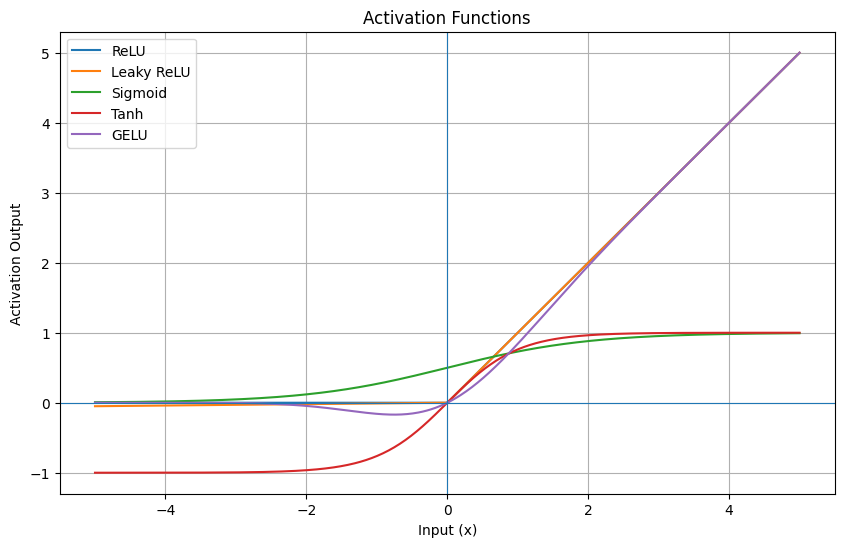

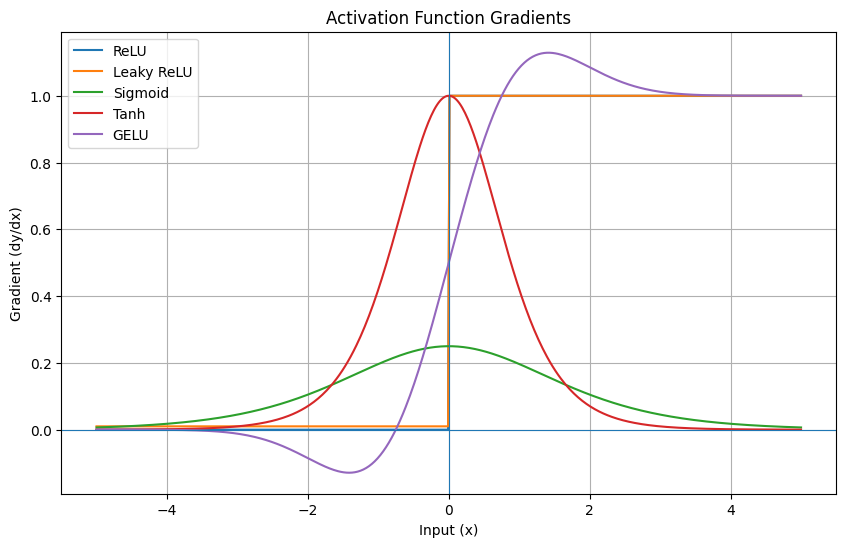

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Input range
x = tf.Variable(
    np.linspace(-5, 5, 500).astype(np.float32)
)

# Activation functions
activations = {
    "ReLU": tf.nn.relu,
    "Leaky ReLU": lambda x: tf.nn.leaky_relu(x, alpha=0.01),
    "Sigmoid": tf.nn.sigmoid,
    "Tanh": tf.nn.tanh,
    "GELU": tf.nn.gelu
}

# Store outputs and gradients
outputs = {}
gradients = {}

for name, activation in activations.items():

    # Calculate activation output
    with tf.GradientTape() as tape:
        tape.watch(x)
        y = activation(x)

    # Calculate dy/dx
    gradient = tape.gradient(y, x)

    outputs[name] = y.numpy()
    gradients[name] = gradient.numpy()


# -----------------------------
# Graph 1: Activation Outputs
# -----------------------------

plt.figure(figsize=(10, 6))

for name in activations:
    plt.plot(x.numpy(), outputs[name], label=name)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Activation Functions")
plt.xlabel("Input (x)")
plt.ylabel("Activation Output")
plt.legend()
plt.grid(True)

plt.show()


# -----------------------------
# Graph 2: Activation Gradients
# -----------------------------

plt.figure(figsize=(10, 6))

for name in activations:
    plt.plot(x.numpy(), gradients[name], label=name)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.title("Activation Function Gradients")
plt.xlabel("Input (x)")
plt.ylabel("Gradient (dy/dx)")
plt.legend()
plt.grid(True)

plt.show()